In [7]:
import os
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pyodbc
import numpy as np

In [8]:
conn= pyodbc.connect(
     "Driver={ODBC Driver 18 for SQL Server};"
    "Server=DESKTOP-55JNORK\\SQLEXPRESS;"
    "Database=phonepe;"
    "Trusted_Connection=yes;"
    "TrustServerCertificate=yes;")
cursor = conn.cursor()
print(" successfully")

 successfully


#  Case 2 – Device Dominance & User Engagement Analysis.

## Scenario

PhonePe aims to understand user preferences across different
device brands and regions.

This analysis focuses on registered users to identify popular
device brands and important states.

## Objective

- Identify the most popular device brands.
- Identify states with the highest registered users.
- Compare user distribution across device brands.
- Identify important regions for user growth.

#### Load data

In [10]:
query2="""
select top 10 *
from aggregated_user;
"""

df2=pd.read_sql(query2, conn)
df2.head(10)

C:\Users\Devendra\AppData\Local\Temp\ipykernel_5892\3894217326.py:6: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df2=pd.read_sql(query2, conn)


,States,Years,Quarter,Brands,Transaction_count,Percentage
0,Andaman & Nicobar,2018,1,Xiaomi,1665,0.247033
1,Andaman & Nicobar,2018,1,Samsung,1445,0.214392
2,Andaman & Nicobar,2018,1,Vivo,982,0.145697
3,Andaman & Nicobar,2018,1,Oppo,501,0.074332
4,Andaman & Nicobar,2018,1,OnePlus,332,0.049258
5,Andaman & Nicobar,2018,1,Realme,316,0.046884
6,Andaman & Nicobar,2018,1,Apple,229,0.033976
7,Andaman & Nicobar,2018,1,Motorola,226,0.033531
8,Andaman & Nicobar,2018,1,Lenovo,202,0.029970
9,Andaman & Nicobar,2018,1,Huawei,158,0.023442


In [11]:
df2["Brands"].unique()

<ArrowStringArray>
[  'Xiaomi',  'Samsung',     'Vivo',     'Oppo',  'OnePlus',   'Realme',
    'Apple', 'Motorola',   'Lenovo',   'Huawei']
Length: 10, dtype: str

# Top 10 States by Users


In [24]:
query = """
SELECT TOP 10
    States,
    SUM(Transaction_count) AS Total_Users
FROM aggregated_user
GROUP BY States
ORDER BY Total_Users DESC
"""

user_states = pd.read_sql(query, conn)

user_states

C:\Users\Devendra\AppData\Local\Temp\ipykernel_5892\3735975161.py:10: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  user_states = pd.read_sql(query, conn)


,States,Total_Users
0,Maharashtra,904150022
1,Uttar Pradesh,711939266
2,Karnataka,582745560
3,Andhra Pradesh,450829670
4,Rajasthan,431291176
5,Telangana,423815506
6,West Bengal,412259550
7,Tamil Nadu,387330056
8,Gujarat,361462616
9,Madhya Pradesh,361324892


# chart

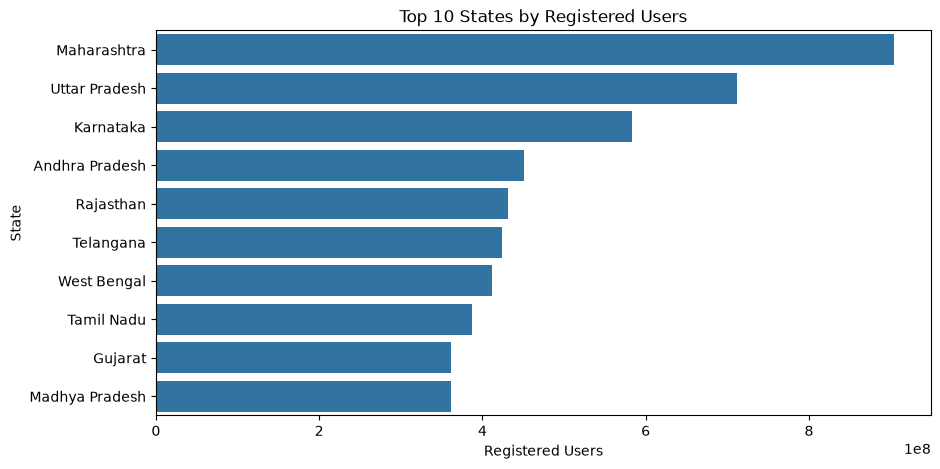

In [25]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=user_states,
    x="Total_Users",
    y="States"
)

plt.title("Top 10 States by Registered Users")
plt.xlabel("Registered Users")
plt.ylabel("State")

plt.show()

# Device Brand Distribution

In [26]:

query = """
SELECT
    Brands,
    SUM(Transaction_count) AS Total_Users
FROM aggregated_user
GROUP BY Brands
ORDER BY Total_Users DESC
"""

brand_users = pd.read_sql(query, conn)

brand_users

C:\Users\Devendra\AppData\Local\Temp\ipykernel_5892\2780529509.py:10: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  brand_users = pd.read_sql(query, conn)


,Brands,Total_Users
0,Xiaomi,1739125234
1,Samsung,1343207422
2,Vivo,1250830038
3,Oppo,840500490
4,Others,565900468
5,Realme,439946444
6,Apple,191894628
7,Motorola,146681468
8,OnePlus,127354422
9,Huawei,114259386


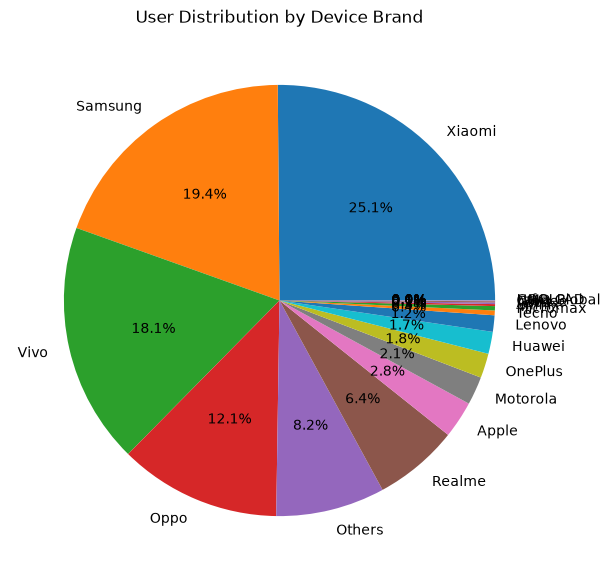

In [28]:
plt.figure(figsize=(7,7))

plt.pie(
    brand_users["Total_Users"],
    labels=brand_users["Brands"],
    autopct="%1.1f%%"
)

plt.title("User Distribution by Device Brand")

plt.show()

### Conclusion

The analysis identifies the states with the highest registered
users and shows the distribution of users across different
device brands.

These insights can help PhonePe improve user engagement and
develop targeted strategies for different regions and devices.